In [186]:
import pandas as pd
import numpy as np
crop_df = pd.read_csv('/content/India Agriculture Crop Production.csv')
rain_df = pd.read_csv('/content/daily-rainfall-at-state-level.csv')

In [187]:
crop_df.head()

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296


In [188]:
crop_df.shape

(345407, 10)

In [189]:
crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345407 entries, 0 to 345406
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   State             345407 non-null  object 
 1   District          345407 non-null  object 
 2   Crop              345375 non-null  object 
 3   Year              345407 non-null  object 
 4   Season            345406 non-null  object 
 5   Area              345374 non-null  float64
 6   Area Units        345407 non-null  object 
 7   Production        340414 non-null  float64
 8   Production Units  345407 non-null  object 
 9   Yield             345374 non-null  float64
dtypes: float64(3), object(7)
memory usage: 26.4+ MB


In [190]:
crop_df.describe()

,Area,Production,Yield
count,3.453740e+05,3.404140e+05,345374.000000
mean,1.167019e+04,9.583711e+05,79.407569
std,4.583843e+04,2.152986e+07,916.628744
min,4.000000e-03,0.000000e+00,0.000000
25%,7.400000e+01,8.700000e+01,0.546742
50%,5.320000e+02,7.170000e+02,1.000000
75%,4.110000e+03,7.176000e+03,2.467080
max,8.580100e+06,1.597800e+09,43958.333333


In [191]:
crop_df.isnull().sum()

,0
State,0
District,0
Crop,32
Year,0
Season,1
Area,33
Area Units,0
Production,4993
Production Units,0
Yield,33


In [192]:
crop_df.duplicated().sum()

np.int64(0)

** Data Cleaning**

In [193]:
crop_df = crop_df.dropna(subset=['Crop'])

In [194]:
crop_df = crop_df.dropna(subset=['Season'])

In [195]:
crop_df = crop_df.dropna(subset=['Area','Yield'])

In [196]:
missing_pct = crop_df['Production'].isnull().mean()*100
print(missing_pct)

1.4361243174066376


In [197]:
crop_df = crop_df.dropna(subset=['Production'])

In [198]:
crop_df.shape

(340414, 10)

In [199]:
crop_df.isnull().sum()

,0
State,0
District,0
Crop,0
Year,0
Season,0
Area,0
Area Units,0
Production,0
Production Units,0
Yield,0


**Rain Dataset**

In [200]:
rain_df.head()

,id,date,state_code,state_name,actual,rfs,normal,deviation
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0


In [201]:
rain_df.shape

(204876, 8)

In [202]:
rain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204876 entries, 0 to 204875
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          204876 non-null  int64  
 1   date        204876 non-null  object 
 2   state_code  204876 non-null  int64  
 3   state_name  204876 non-null  object 
 4   actual      187714 non-null  float64
 5   rfs         199011 non-null  float64
 6   normal      193358 non-null  float64
 7   deviation   173855 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 12.5+ MB


In [203]:
rain_df.describe()

,id,state_code,actual,rfs,normal,deviation
count,204876.000000,204876.000000,187714.000000,199011.000000,193358.000000,173855.000000
mean,102437.500000,19.166667,3.990693,9.643683,4.654058,38.516222
std,59142.751213,11.171668,9.512507,27.504865,7.369770,1367.744520
min,0.000000,1.000000,0.000000,0.000000,0.000000,-100.000000
25%,51218.750000,9.750000,0.000000,0.000000,0.420000,-100.000000
50%,102437.500000,18.500000,0.150000,0.063856,1.870000,-89.060000
75%,153656.250000,29.250000,3.890000,5.685068,6.760000,-9.045000
max,204875.000000,38.000000,283.000000,658.765073,97.680000,362300.000000


In [204]:
rain_df.isnull().sum()

,0
id,0
date,0
state_code,0
state_name,0
actual,17162
rfs,5865
normal,11518
deviation,31021


In [205]:
rain_df.duplicated().sum()

np.int64(0)

In [206]:
rain_df['date'] = pd.to_datetime(rain_df['date'])

print(rain_df['date'].min())
print(rain_df['date'].max())

2009-01-01 00:00:00
2024-07-31 00:00:00


Data Cleaning

In [207]:
rain_df.isnull().sum()

,0
id,0
date,0
state_code,0
state_name,0
actual,17162
rfs,5865
normal,11518
deviation,31021


In [208]:
for col in ['actual', 'normal', 'rfs', 'deviation']:
    rain_df[col] = rain_df[col].fillna(
        rain_df.groupby('state_name')[col].transform('median')
    )

In [209]:
rain_df.isnull().sum()

,0
id,0
date,0
state_code,0
state_name,0
actual,11382
rfs,5691
normal,11382
deviation,17073


EDA analyses

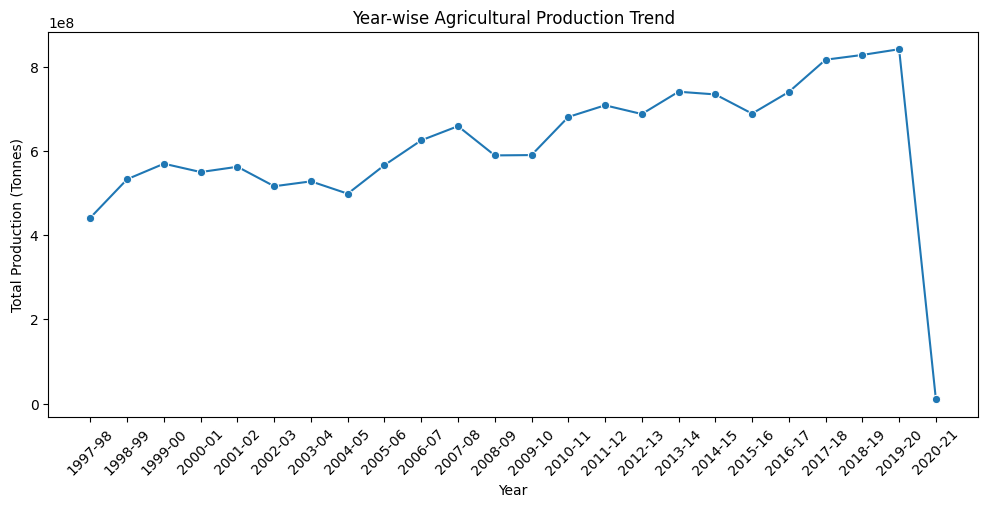

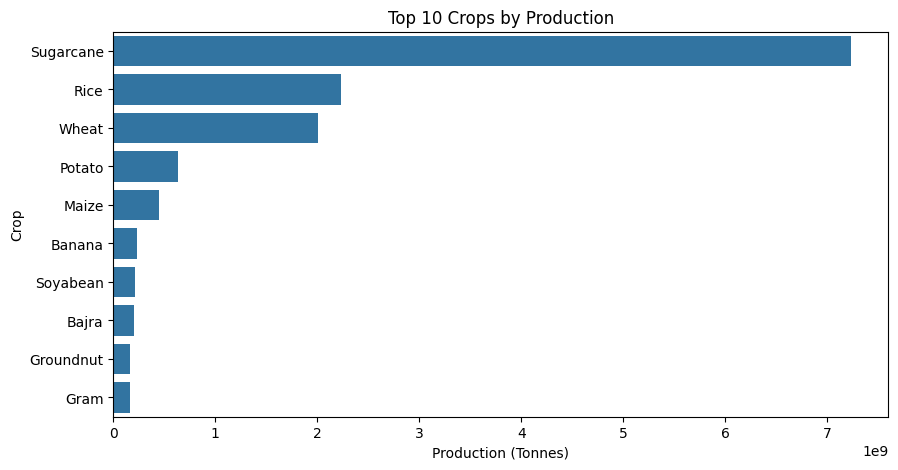

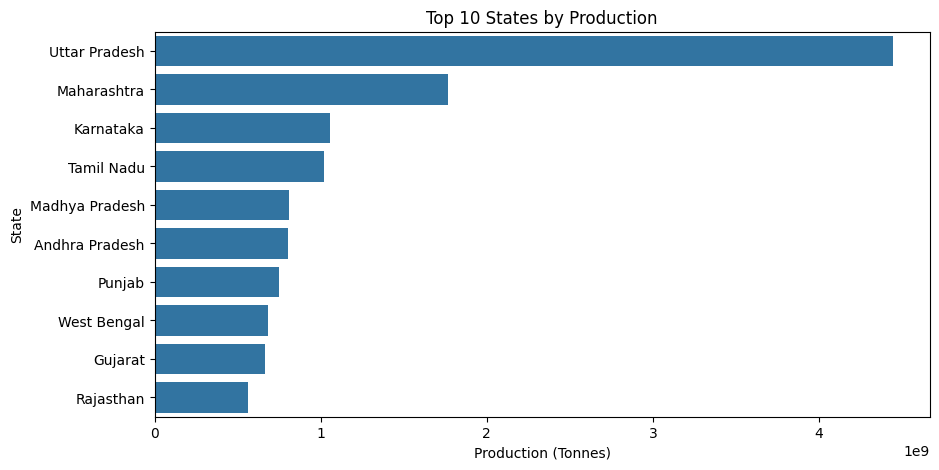

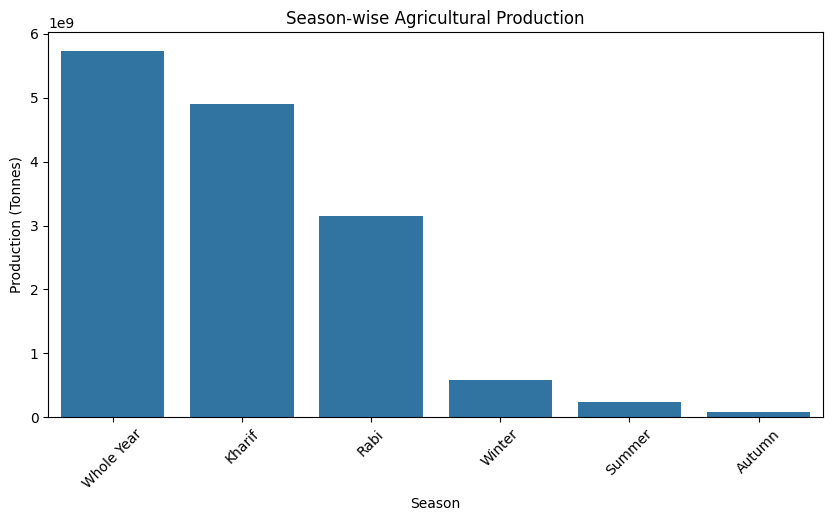

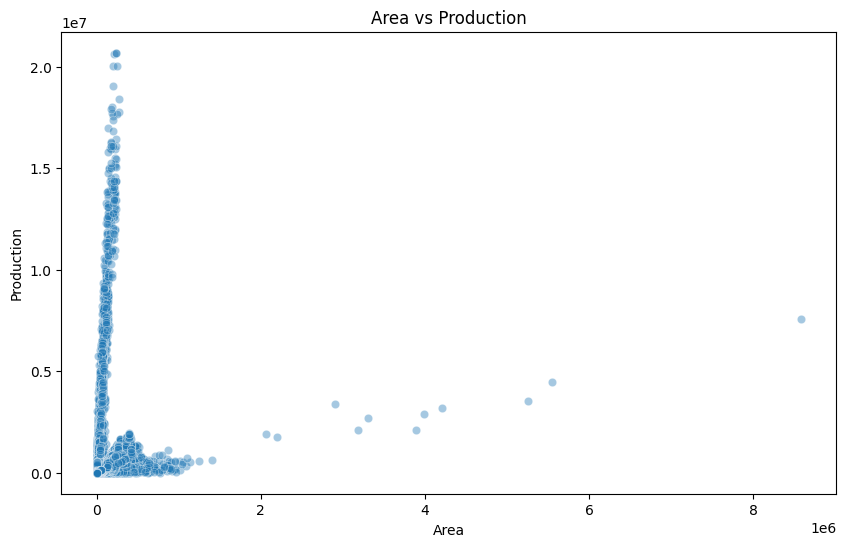

In [210]:
import matplotlib.pyplot as plt
import seaborn as sns

tonnes_df = crop_df[
    crop_df['Production Units'].str.lower() == 'tonnes'
].copy()

year_production = tonnes_df.groupby('Year')['Production'].sum()

plt.figure(figsize=(12,5))
sns.lineplot(x=year_production.index, y=year_production.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Total Production (Tonnes)")
plt.title("Year-wise Agricultural Production Trend")
plt.show()

top_crops = (
    tonnes_df.groupby('Crop')['Production']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_crops.values, y=top_crops.index)
plt.xlabel("Production (Tonnes)")
plt.ylabel("Crop")
plt.title("Top 10 Crops by Production")
plt.show()


top_states = (
    tonnes_df.groupby('State')['Production']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_states.values, y=top_states.index)
plt.xlabel("Production (Tonnes)")
plt.ylabel("State")
plt.title("Top 10 States by Production")
plt.show()


season_production = (
    tonnes_df.groupby('Season')['Production']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(x=season_production.index, y=season_production.values)
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")
plt.title("Season-wise Agricultural Production")
plt.xticks(rotation=45)
plt.show()



plt.figure(figsize=(10,6))
sns.scatterplot(
    data=tonnes_df,
    x='Area',
    y='Production',
    alpha=0.4
)
plt.xlabel("Area")
plt.ylabel("Production")
plt.title("Area vs Production")
plt.show()


EDA analyses

In [211]:
rain_df['date'] = pd.to_datetime(rain_df['date'])
rain_df['Year'] = rain_df['date'].dt.year

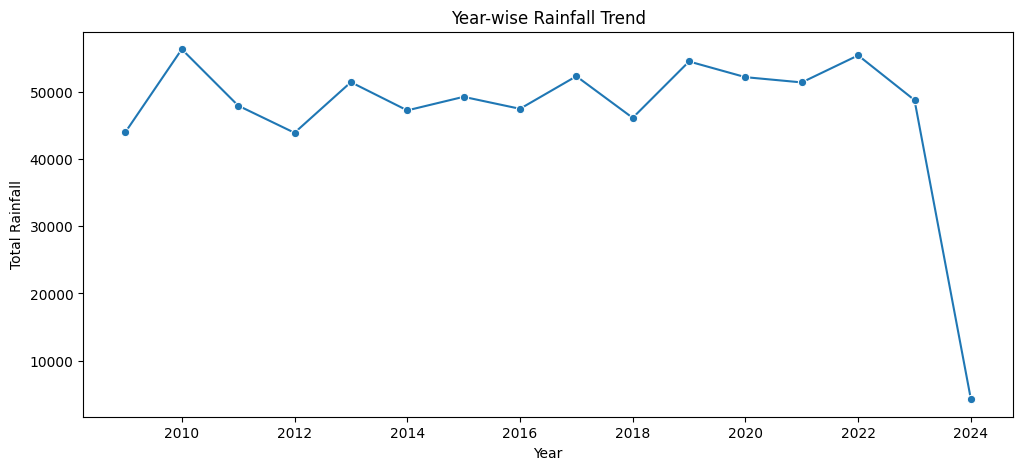

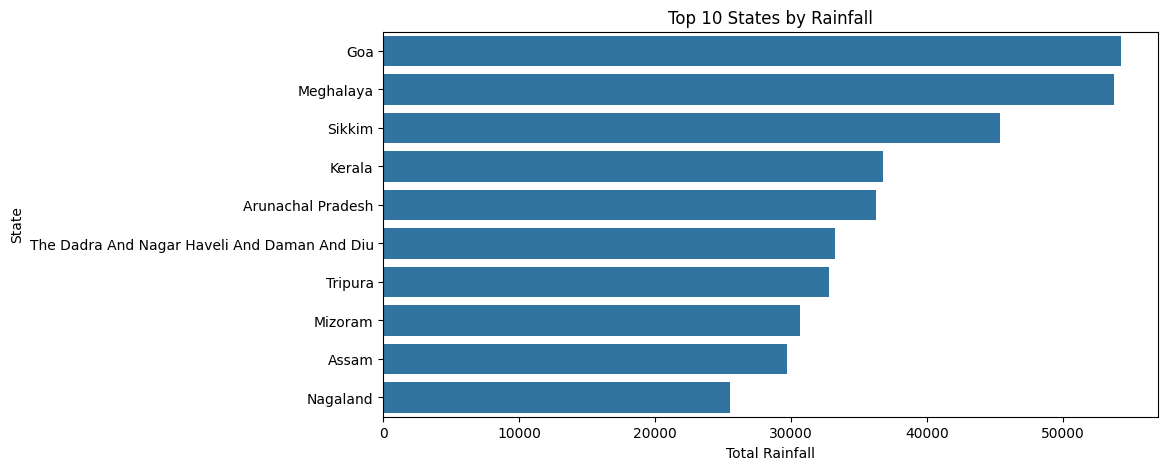

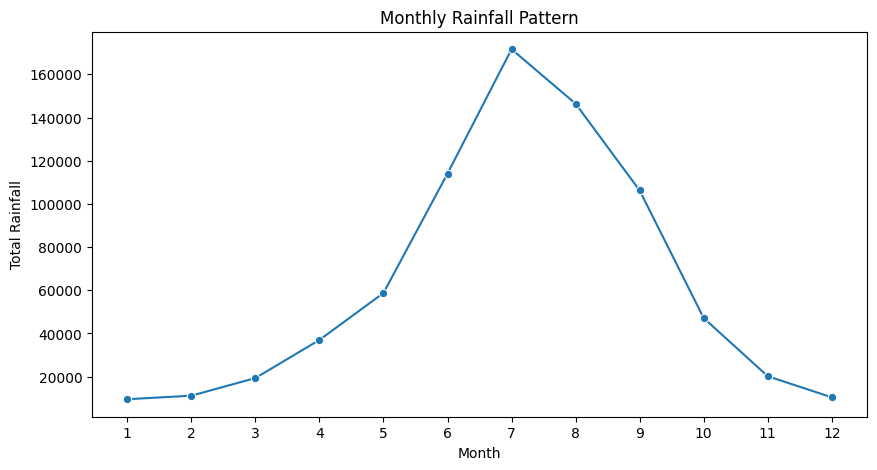

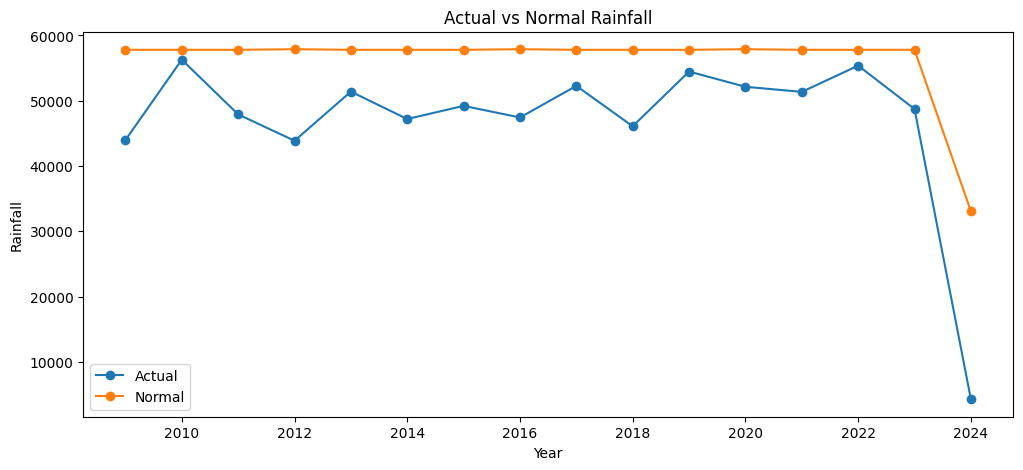

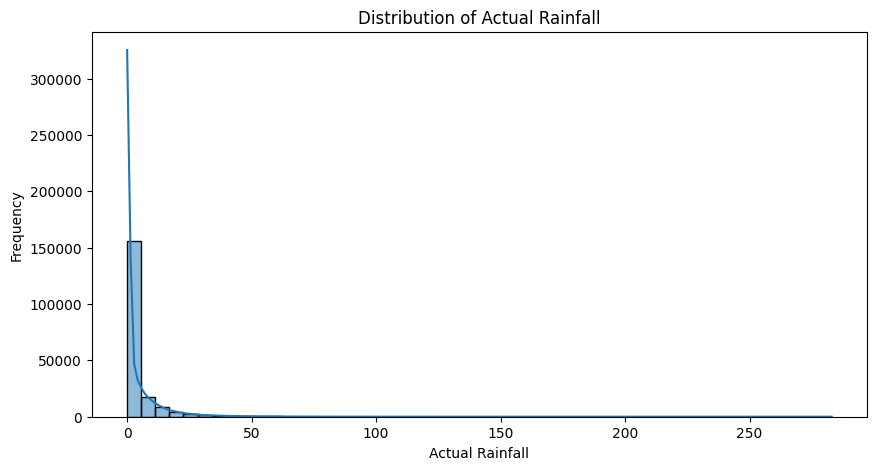

In [212]:
year_rainfall = rain_df.groupby('Year')['actual'].sum()

plt.figure(figsize=(12,5))
sns.lineplot(x=year_rainfall.index, y=year_rainfall.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Total Rainfall")
plt.title("Year-wise Rainfall Trend")
plt.show()


top_rainfall_states = (
    rain_df.groupby('state_name')['actual']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_rainfall_states.values,
    y=top_rainfall_states.index
)
plt.xlabel("Total Rainfall")
plt.ylabel("State")
plt.title("Top 10 States by Rainfall")
plt.show()


rain_df['Month'] = rain_df['date'].dt.month

monthly_rainfall = rain_df.groupby('Month')['actual'].sum()

plt.figure(figsize=(10,5))
sns.lineplot(
    x=monthly_rainfall.index,
    y=monthly_rainfall.values,
    marker='o'
)
plt.xlabel("Month")
plt.ylabel("Total Rainfall")
plt.title("Monthly Rainfall Pattern")
plt.xticks(range(1,13))
plt.show()


rain_summary = rain_df.groupby('Year')[['actual','normal']].sum()

plt.figure(figsize=(12,5))
plt.plot(rain_summary.index, rain_summary['actual'], marker='o', label='Actual')
plt.plot(rain_summary.index, rain_summary['normal'], marker='o', label='Normal')

plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.title("Actual vs Normal Rainfall")
plt.legend()
plt.show()


plt.figure(figsize=(10,5))
sns.histplot(rain_df['actual'], bins=50, kde=True)
plt.xlabel("Actual Rainfall")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Rainfall")
plt.show()

Crop Dataset Outlier Analysis

In [213]:
crop_num_cols = ['Area', 'Production', 'Yield']

In [214]:
for col in crop_num_cols:
    Q1 = crop_df[col].quantile(0.25)
    Q3 = crop_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = crop_df[
        (crop_df[col] < lower) |
        (crop_df[col] > upper)
    ]
    print("Outliers    :", len(outliers))
    print("Percentage  :", round(len(outliers) / len(crop_df) * 100, 2), "%")
    print("-" * 50)

Outliers    : 56525
Percentage  : 16.6 %
--------------------------------------------------
Outliers    : 60092
Percentage  : 17.65 %
--------------------------------------------------
Outliers    : 51328
Percentage  : 15.08 %
--------------------------------------------------


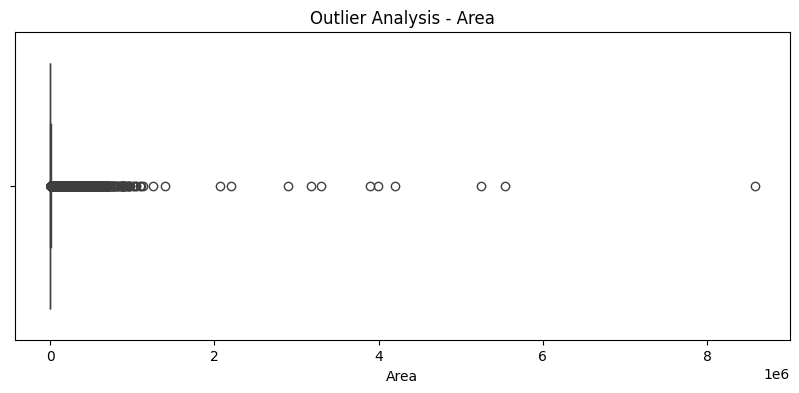

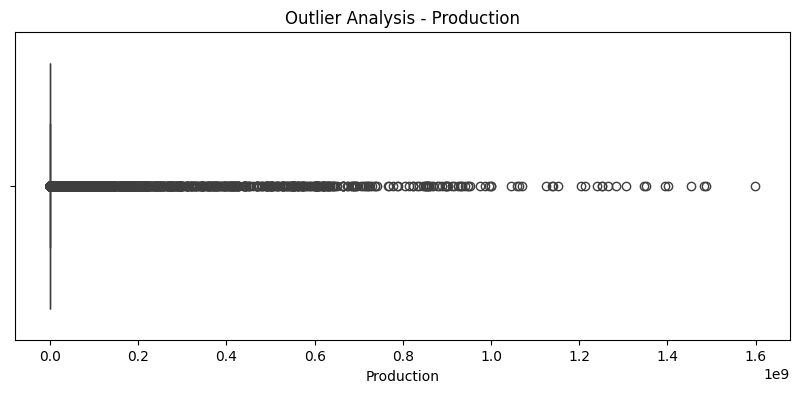

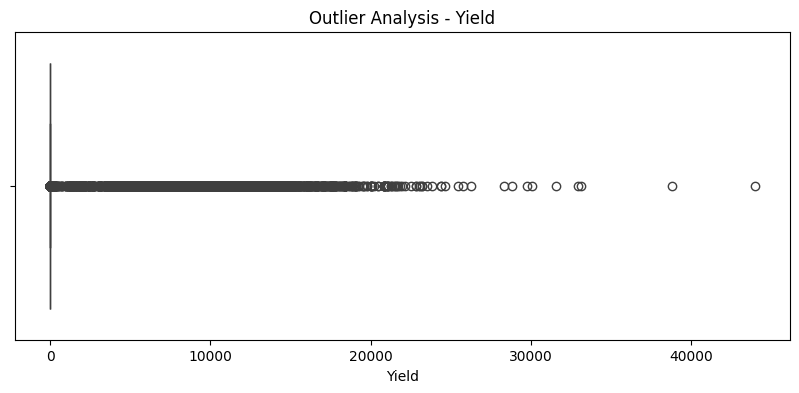

In [215]:
for col in crop_num_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=crop_df[col])
    plt.title(f"Outlier Analysis - {col}")
    plt.show()

Crop Dataset Correlation Analysis

In [216]:
crop_corr = crop_df[['Area', 'Production', 'Yield']].corr()

print(crop_corr)

                Area  Production     Yield
Area        1.000000    0.048521  0.000133
Production  0.048521    1.000000  0.437400
Yield       0.000133    0.437400  1.000000


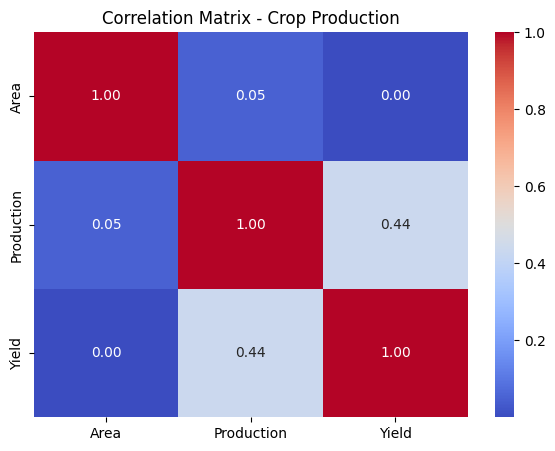

In [217]:
plt.figure(figsize=(7,5))

sns.heatmap(
    crop_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix - Crop Production")
plt.show()

Rain Dataset  Outlier Analysis



In [218]:
rain_num_cols = ['actual', 'normal', 'rfs']

In [219]:
for col in rain_num_cols:
    Q1 = rain_df[col].quantile(0.25)
    Q3 = rain_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = rain_df[
        (rain_df[col] < lower) |
        (rain_df[col] > upper)
    ]

    print(f"{col}")
    print("Lower Bound :", lower)
    print("Upper Bound :", upper)
    print("Outliers    :", len(outliers))
    print("Percentage  :", round(len(outliers) / len(rain_df) * 100, 2), "%")
    print("-" * 50)

actual
Lower Bound : -5.475
Upper Bound : 9.125
Outliers    : 25634
Percentage  : 12.51 %
--------------------------------------------------
normal
Lower Bound : -9.09
Upper Bound : 16.27
Outliers    : 7710
Percentage  : 3.76 %
--------------------------------------------------
rfs
Lower Bound : -8.5066875
Upper Bound : 14.1778125
Outliers    : 32149
Percentage  : 15.69 %
--------------------------------------------------


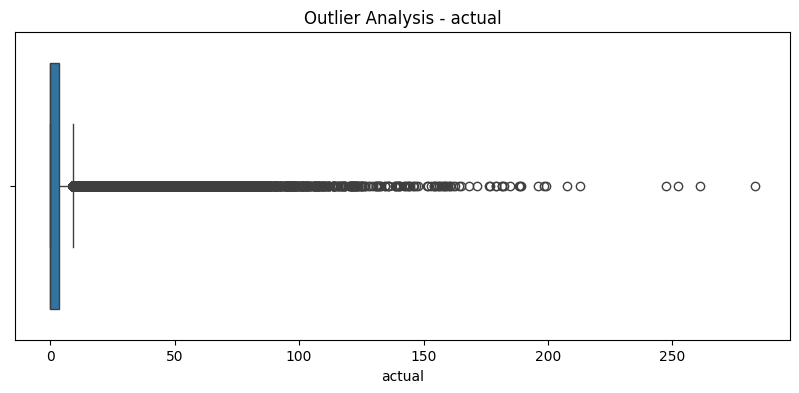

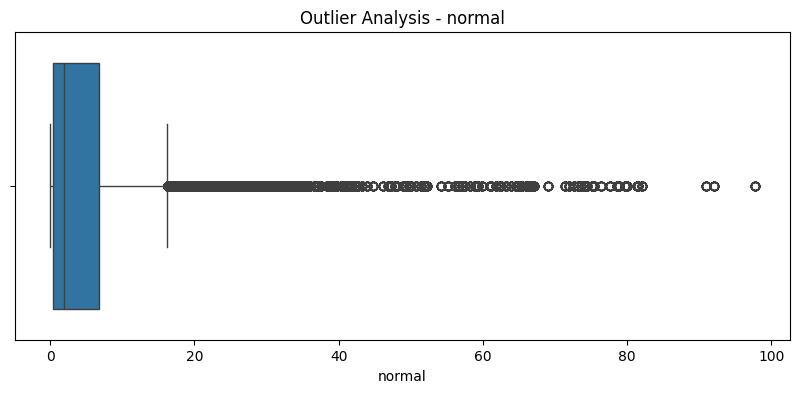

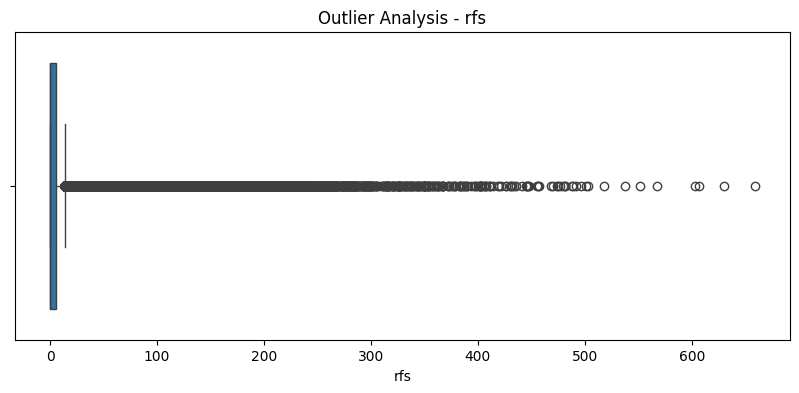

In [220]:
for col in rain_num_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=rain_df[col])
    plt.title(f"Outlier Analysis - {col}")
    plt.show()

Rain Dataset Correlation Analysis

In [221]:
rain_corr = rain_df[['actual', 'normal', 'rfs']].corr()

print(rain_corr)

          actual    normal       rfs
actual  1.000000  0.432958  0.501512
normal  0.432958  1.000000  0.180579
rfs     0.501512  0.180579  1.000000


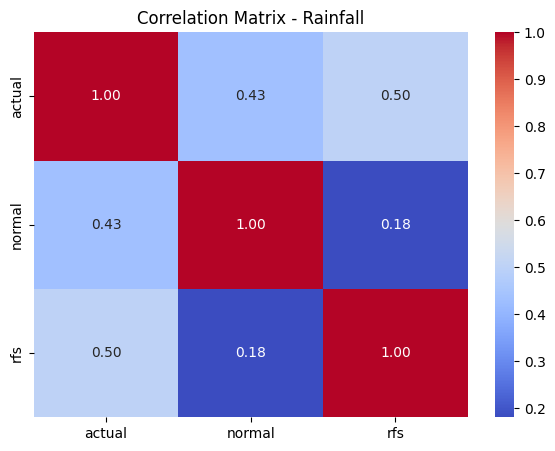

In [222]:
plt.figure(figsize=(7,5))

sns.heatmap(
    rain_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix - Rainfall")
plt.show()

Prepare Rainfall Dataset

In [223]:
# Convert date column to datetime
rain_df['date'] = pd.to_datetime(rain_df['date'])

# Extract year and month
rain_df['Rain_Year'] = rain_df['date'].dt.year
rain_df['Month'] = rain_df['date'].dt.month

# Create Agricultural Year (Crop Year)
rain_df['Crop_Year'] = np.where(
    rain_df['Month'] >= 7,
    rain_df['Rain_Year'].astype(str) + '-' +
    (rain_df['Rain_Year'] + 1).astype(str).str[-2:],

    (rain_df['Rain_Year'] - 1).astype(str) + '-' +
    rain_df['Rain_Year'].astype(str).str[-2:]
)

# Aggregate rainfall at State + Crop Year level
rain_yearly = (
    rain_df.groupby(['state_name', 'Crop_Year'])
    .agg(
        Actual_Rainfall=('actual', lambda x: x.sum(min_count=1)),
        Normal_Rainfall=('normal', lambda x: x.sum(min_count=1))
    )
    .reset_index()
)

# Rename column to match crop dataset
rain_yearly.rename(
    columns={'state_name': 'State'},
    inplace=True
)


MERGECROP + RAINFALL DATASET

In [224]:
# Create Crop_Year in crop dataset
crop_df['Crop_Year'] = crop_df['Year']

# Merge datasets
final_df = pd.merge(
    crop_df,
    rain_yearly,
    on=['State', 'Crop_Year'],
    how='left'
)

# Check result
print("Final Dataset Shape:", final_df.shape)

print("\nMissing Values:")
print(
    final_df[['Actual_Rainfall', 'Normal_Rainfall']]
    .isnull()
    .sum()
)

# View merged dataset
final_df.head()

Final Dataset Shape: (340414, 13)

Missing Values:
Actual_Rainfall    148833
Normal_Rainfall    148833
dtype: int64


,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield,Crop_Year,Actual_Rainfall,Normal_Rainfall
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541,2001-02,NaN,NaN
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803,2002-03,NaN,NaN
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358,2003-04,NaN,NaN
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000,2001-02,NaN,NaN
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296,2002-03,NaN,NaN


 FEATURE ENGINEERING + MODEL DATASETS

In [225]:
import numpy as np

# Create working dataset
model_df = final_df.copy()

# Convert Crop Year to Numeric Year
# Example: 2008-09 -> 2008

model_df['Year_Number'] = (
    model_df['Crop_Year']
    .str[:4]
    .astype(int)
)

# Rainfall Deviation
model_df['Rainfall_Deviation'] = (
    model_df['Actual_Rainfall']
    - model_df['Normal_Rainfall']
)

# Rainfall Ratio

model_df['Rainfall_Ratio'] = np.where(
    model_df['Normal_Rainfall'] != 0,
    model_df['Actual_Rainfall'] /
    model_df['Normal_Rainfall'],
    np.nan
)

# Dataset WITHOUT Rainfall

df_no_rain = model_df.copy()

# Dataset WITH Rainfall

df_rain = model_df.dropna(
    subset=[
        'Actual_Rainfall',
        'Normal_Rainfall'
    ]
).copy()

# Show results

print("WITHOUT RAINFALL DATASET")
print(df_no_rain.shape)

print("\nWITH RAINFALL DATASET")
print(df_rain.shape)

print("\nColumns Available")
print(df_no_rain.columns.tolist())

print("\nMissing Values in Rain Dataset")
print(df_rain.isnull().sum())

print("\nSample Data")
print(df_rain.head())

WITHOUT RAINFALL DATASET
(340414, 16)

WITH RAINFALL DATASET
(191581, 16)

Columns Available
['State', 'District', 'Crop', 'Year', 'Season', 'Area', 'Area Units', 'Production', 'Production Units', 'Yield', 'Crop_Year', 'Actual_Rainfall', 'Normal_Rainfall', 'Year_Number', 'Rainfall_Deviation', 'Rainfall_Ratio']

Missing Values in Rain Dataset
State                 0
District              0
Crop                  0
Year                  0
Season                0
Area                  0
Area Units            0
Production            0
Production Units      0
Yield                 0
Crop_Year             0
Actual_Rainfall       0
Normal_Rainfall       0
Year_Number           0
Rainfall_Deviation    0
Rainfall_Ratio        0
dtype: int64

Sample Data
                State       District      Crop     Year      Season   Area  \
83848  Andhra Pradesh      ANANTAPUR  Arecanut  2008-09  Whole Year  325.0   
83849  Andhra Pradesh      ANANTAPUR  Arecanut  2009-10  Whole Year  356.0   
83850  Andhr

RANDOM FOREST MODELS WITH RAINFALL vs WITHOUT RAINFALL

In [228]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score

# =====================================================
# SAMPLE DATA
# =====================================================

df_no_rain_sample = df_no_rain.sample(
    n=50000,
    random_state=42
)

df_rain_sample = df_rain.sample(
    n=50000,
    random_state=42
)

# =====================================================
# WITHOUT RAINFALL
# =====================================================

print("="*60)
print("WITHOUT RAINFALL MODELS")
print("="*60)

# -------------------------------
# Crop Prediction
# -------------------------------

crop_features_nr = [
    'State',
    'District',
    'Season',
    'Year_Number',
    'Area'
]

X = df_no_rain_sample[crop_features_nr]
y = df_no_rain_sample['Crop']

cat_cols = ['State','District','Season']
num_cols = ['Year_Number','Area']

preprocessor = ColumnTransformer(
    [
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

crop_model_nr = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=20,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

crop_model_nr.fit(X_train, y_train)

pred = crop_model_nr.predict(X_test)

print("Crop Accuracy :", accuracy_score(y_test, pred))

# -------------------------------
# Production Prediction
# -------------------------------

prod_features_nr = [
    'State',
    'District',
    'Crop',
    'Season',
    'Year_Number',
    'Area'
]

X = df_no_rain_sample[prod_features_nr]
y = df_no_rain_sample['Production']

cat_cols = ['State','District','Crop','Season']
num_cols = ['Year_Number','Area']

preprocessor = ColumnTransformer(
    [
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

prod_model_nr = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=20,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

prod_model_nr.fit(X_train, y_train)

pred = prod_model_nr.predict(X_test)

print("Production R2 :", r2_score(y_test, pred))

# -------------------------------
# Yield Prediction
# -------------------------------

yield_features_nr = [
    'State',
    'District',
    'Crop',
    'Season',
    'Year_Number',
    'Area'
]

X = df_no_rain_sample[yield_features_nr]
y = df_no_rain_sample['Yield']

cat_cols = ['State','District','Crop','Season']
num_cols = ['Year_Number','Area']

preprocessor = ColumnTransformer(
    [
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

yield_model_nr = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=20,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

yield_model_nr.fit(X_train, y_train)

pred = yield_model_nr.predict(X_test)

print("Yield R2 :", r2_score(y_test, pred))

# =====================================================
# WITH RAINFALL
# =====================================================

print("\n")
print("="*60)
print("WITH RAINFALL MODELS")
print("="*60)

# -------------------------------
# Crop Prediction
# -------------------------------

crop_features_r = [
    'State',
    'District',
    'Season',
    'Year_Number',
    'Area',
    'Actual_Rainfall',
    'Normal_Rainfall',
    'Rainfall_Deviation',
    'Rainfall_Ratio'
]

X = df_rain_sample[crop_features_r]
y = df_rain_sample['Crop']

cat_cols = ['State','District','Season']
num_cols = [
    'Year_Number',
    'Area',
    'Actual_Rainfall',
    'Normal_Rainfall',
    'Rainfall_Deviation',
    'Rainfall_Ratio'
]

preprocessor = ColumnTransformer(
    [
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

crop_model_r = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=20,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

crop_model_r.fit(X_train, y_train)

pred = crop_model_r.predict(X_test)

print("Crop Accuracy :", accuracy_score(y_test, pred))

# -------------------------------
# Production Prediction
# -------------------------------

prod_features_r = [
    'State','District','Crop','Season',
    'Year_Number','Area',
    'Actual_Rainfall','Normal_Rainfall',
    'Rainfall_Deviation','Rainfall_Ratio'
]

X = df_rain_sample[prod_features_r]
y = df_rain_sample['Production']

cat_cols = ['State','District','Crop','Season']
num_cols = [
    'Year_Number','Area',
    'Actual_Rainfall','Normal_Rainfall',
    'Rainfall_Deviation','Rainfall_Ratio'
]

preprocessor = ColumnTransformer(
    [
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

prod_model_r = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=20,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

prod_model_r.fit(X_train, y_train)

pred = prod_model_r.predict(X_test)

print("Production R2 :", r2_score(y_test, pred))

# -------------------------------
# Yield Prediction
# -------------------------------

yield_features_r = prod_features_r

X = df_rain_sample[yield_features_r]
y = df_rain_sample['Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

yield_model_r = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=20,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

yield_model_r.fit(X_train, y_train)

pred = yield_model_r.predict(X_test)

print("Yield R2 :", r2_score(y_test, pred))

WITHOUT RAINFALL MODELS
Crop Accuracy : 0.166
Production R2 : 0.9374793080787347
Yield R2 : 0.6962991076827616


WITH RAINFALL MODELS
Crop Accuracy : 0.155
Production R2 : 0.9387366682227193
Yield R2 : 0.9169180485060632


In [230]:
# =====================================================
# FORECAST 2027 - 2032
# =====================================================

future_years = [2027, 2028, 2029, 2030, 2031, 2032]

forecast_base = df_rain_sample[
    [
        'State',
        'District',
        'Crop',
        'Season',
        'Area',
        'Actual_Rainfall',
        'Normal_Rainfall',
        'Rainfall_Deviation',
        'Rainfall_Ratio'
    ]
].drop_duplicates()

forecast_list = []

for year in future_years:

    temp = forecast_base.copy()

    temp['Year_Number'] = year

    forecast_list.append(temp)

future_df = pd.concat(
    forecast_list,
    ignore_index=True
)

# =====================================================
# PRODUCTION FORECAST
# =====================================================

future_df['Predicted_Production'] = prod_model_r.predict(
    future_df[
        [
            'State',
            'District',
            'Crop',
            'Season',
            'Year_Number',
            'Area',
            'Actual_Rainfall',
            'Normal_Rainfall',
            'Rainfall_Deviation',
            'Rainfall_Ratio'
        ]
    ]
)

# =====================================================
# YIELD FORECAST
# =====================================================

future_df['Predicted_Yield'] = yield_model_r.predict(
    future_df[
        [
            'State',
            'District',
            'Crop',
            'Season',
            'Year_Number',
            'Area',
            'Actual_Rainfall',
            'Normal_Rainfall',
            'Rainfall_Deviation',
            'Rainfall_Ratio'
        ]
    ]
)

# =====================================================
# RESULTS
# =====================================================

print("Forecast Dataset Shape:")
print(future_df.shape)

print("\nForecast Sample:")
print(
    future_df[
        [
            'State',
            'District',
            'Crop',
            'Year_Number',
            'Predicted_Production',
            'Predicted_Yield'
        ]
    ].head(20)
)

Forecast Dataset Shape:
(300000, 12)

Forecast Sample:
             State         District               Crop  Year_Number  \
0        Karnataka        DAVANGERE          Groundnut         2027   
1          Mizoram         SERCHHIP              Maize         2027   
2            Bihar          KATIHAR  Moong(Green Gram)         2027   
3    Uttar Pradesh     SHAHJAHANPUR             Potato         2027   
4           Odisha       KENDRAPARA         Horse-gram         2027   
5         Nagaland         LONGLENG               Rice         2027   
6        Rajasthan            ALWAR               Moth         2027   
7   Andhra Pradesh    EAST GODAVARI               Rice         2027   
8        Rajasthan       PRATAPGARH              Bajra         2027   
9        Karnataka           HAVERI              Jowar         2027   
10           Bihar           ARARIA  Moong(Green Gram)         2027   
11   Uttar Pradesh         AZAMGARH      Small millets         2027   
12       Karnataka    

The study integrated crop production data with rainfall data
to evaluate the impact of weather conditions on agricultural
forecasting.

Results show that rainfall information significantly improves
yield prediction, moderately improves production prediction,
and has little influence on crop selection prediction.

Therefore, rainfall variables should be incorporated into
yield forecasting models to improve prediction accuracy.